In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Plegma_Programming\PLEGMA_final_hourly_dataset.csv")

# One-hot encode μόνο το συγκεκριμένο feature αν δεν υπάρχει ήδη
if "years_in_house_gt_5_years" not in df.columns:
    df = pd.get_dummies(df, columns=["years_in_house"], drop_first=False)

target = "consumption_Wh"

numeric_cols = [
    "consumption_Wh",
    "internal_temperature",
    "external_temperature",
    "internal_humidity",
    "external_humidity",
    "num_rooms",
    "residents"
]

cols = numeric_cols + ["years_in_house_gt_5_years"]

corr = df[cols].corr()

print("\nCorrelation with target:")
print(corr[target].sort_values(ascending=False))


Correlation with target:
consumption_Wh               1.000000
residents                    0.160494
years_in_house_gt_5_years    0.101104
internal_temperature         0.062906
external_temperature         0.042396
num_rooms                    0.013438
external_humidity           -0.052253
internal_humidity           -0.133252
Name: consumption_Wh, dtype: float64


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Plegma_Programming\PLEGMA_final_hourly_dataset.csv")

# Ensure encoding
df = pd.get_dummies(df, columns=["years_in_house"], drop_first=False)

grouped = df.groupby("years_in_house_gt_5_years")["consumption_Wh"].agg([
    "mean", "median", "std", "count"
])

print("\nConsumption by years_in_house_gt_5_years:")
print(grouped)


Consumption by years_in_house_gt_5_years:
                                 mean      median         std  count
years_in_house_gt_5_years                                           
False                      286.090028   73.567289  554.729167  31737
True                       403.750889  176.160328  591.819578  39374


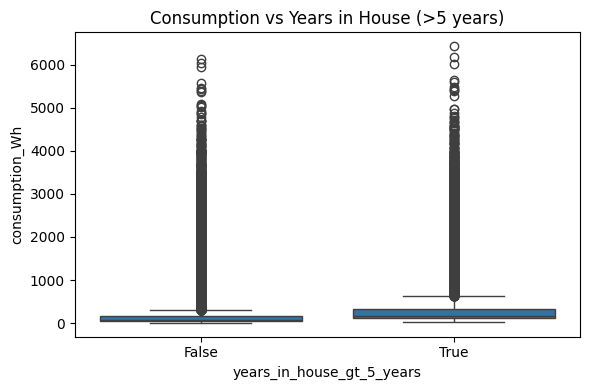

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(r"C:\Plegma_Programming\PLEGMA_final_hourly_dataset.csv")
df = pd.get_dummies(df, columns=["years_in_house"], drop_first=False)

plt.figure(figsize=(6,4))
sns.boxplot(x="years_in_house_gt_5_years", y="consumption_Wh", data=df)
plt.title("Consumption vs Years in House (>5 years)")
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Plegma_Programming\PLEGMA_final_hourly_dataset.csv")
df = pd.get_dummies(df, columns=["years_in_house"], drop_first=False)

# Μέσος αριθμός δωματίων ανά κατηγορία
print("\nRooms:")
print(df.groupby("years_in_house_gt_5_years")["num_rooms"].mean())

# Μέσο income proxy
if "income_band" in df.columns:
    print("\nIncome distribution:")
    print(pd.crosstab(df["years_in_house_gt_5_years"], df["income_band"], normalize="index"))

# Residents
print("\nResidents:")
print(df.groupby("years_in_house_gt_5_years")["residents"].mean())


Rooms:
years_in_house_gt_5_years
False    3.520686
True     3.472190
Name: num_rooms, dtype: float64

Income distribution:
income_band                2_to_4_wages  4_to_6_wages  up_to_1_wage  \
years_in_house_gt_5_years                                             
False                          0.337650      0.479314      0.183036   
True                           0.469879      0.315792      0.000000   

income_band                up_to_2_wages  
years_in_house_gt_5_years                 
False                           0.000000  
True                            0.214329  

Residents:
years_in_house_gt_5_years
False    1.00000
True     2.04663
Name: residents, dtype: float64
